# 05 — ML-augmented assimilation (Howard et al. 2024 style)

Evaluated on the **independent test set** from notebook 02 (`*_test.nc`, 200
cycles, a different trajectory than the one the CNN was trained on). Inference
runs locally (CPU is fine). Four methods:

1. **EnKF 100%** — dense-obs EnKF every step (expensive upper baseline).
2. **EnKF 25% + skip** — sparse EnKF every *other* step, forecast-only in between
   (cheap baseline: `schedule=["enkf","skip"]`).
3. **EnKF 25% + ML** — replace the skipped step by an ML analysis that reads the
   **dense** observations (`schedule=["enkf","ml"]`, `ml_obs=obs_full`). This is
   the Howard idea: ML cheaply exploits the dense obs the sparse EnKF skips.
4. **ML every step** — the CNN alone (emulating the dense EnKF).

The key comparison is **EnKF 25% + skip vs EnKF 25% + ML**. The `schedule`
mechanism generalizes to future sequences like `["enkf","ml","skip"]`.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt, xarray as xr
%matplotlib inline
import torch
from QG_2D import QG2D
from Experiment import Experiment, _save_run
from ml_model import CNNAssimilator, get_device

device = get_device()
DT = 0.01
os.makedirs("da_data", exist_ok=True)

No GPU found -- using CPU. Training will be slow; consider running this notebook on Google Colab (GPU runtime).


## Load the test set (from notebook 02) and the trained CNN

Needs `da_data/{truth_test,control_test,obs_full_test,obs_sparse_test}.nc` and
`ml_weights/cnn.pt` (from notebook 04). A short test set is generated if missing.

In [3]:
def _generate_test(nc=24, obs_every=24, seed=142):
    P=dict(N=64,beta=0.0,mu=0.1,nu=1e-3,p=2,A=4.0,k_f=4); m=QG2D(**P)
    qh=np.fft.fft2(m.random_ic(seed=seed,amp=2.0))
    for _ in range(int(40/DT)): qh=m.step(qh,DT)
    q0=np.real(np.fft.ifft2(qh)); clim=q0.std()
    d=m.random_ic(seed=seed+1,amp=1.0); d*=0.05*clim/d.std(); win=nc*obs_every*DT
    m.run(q0,tf=win,dt=DT,spinup=0,store_every=obs_every,path="da_data/control_test.nc")
    truth=m.run(q0+d,tf=win,dt=DT,spinup=0,store_every=obs_every,path="da_data/truth_test.nc")
    sig=0.1*float(truth.q.std()); rng=np.random.default_rng(seed+7); N=P["N"]
    for frac,path in [(1.0,"da_data/obs_full_test.nc"),(0.25,"da_data/obs_sparse_test.nc")]:
        mask=np.zeros(N*N,bool)
        if frac>=1: mask[:]=True
        else: mask[rng.choice(N*N,int(frac*N*N),replace=False)]=True
        mask=mask.reshape(N,N)
        o=np.where(mask[None],truth.q.values+rng.normal(0,sig,truth.q.shape),np.nan)
        _save_run(xr.Dataset({"obs":(("time","y","x"),o),"mask":(("y","x"),mask.astype("i1"))},
                  coords={"time":truth.time,"y":truth.y,"x":truth.x},
                  attrs={**P,"sigma_obs":sig,"dt_obs":obs_every*DT,"coverage":float(mask.mean())}),path)

need=["truth_test","control_test","obs_full_test","obs_sparse_test"]
if not all(os.path.exists(f"da_data/{f}.nc") for f in need):
    print("test set missing -> generating a short one (run notebook 02 for the 200-cycle set)...")
    _generate_test()

truth=QG2D.load("da_data/truth_test.nc"); control=QG2D.load("da_data/control_test.nc")
obs_full=QG2D.load("da_data/obs_full_test.nc"); obs_sparse=QG2D.load("da_data/obs_sparse_test.nc")
mp={k:truth.attrs[k] for k in ["N","L","beta","mu","nu","p","A","k_f"]}
x0=control.q.isel(time=0).values; N=int(truth.attrs["N"])
NC=truth.sizes["time"]-1

assert os.path.exists("ml_weights/cnn.pt"), "train the CNN first (notebook 04)"
cnn=CNNAssimilator.load("ml_weights/cnn.pt", N, device=device)
print("test cycles:", NC)

test cycles: 1200


## Run the four methods

In [4]:
base=dict(nens=20, dt=DT, gamma=1.1, loc=1.0, init_spread=0.1)
def run(obs, **kw):
    return Experiment(mp, truth, obs, base).assimilate(ncycles=NC, x0=x0, progress=True, **kw)

results = {
    "EnKF 100%":       run(obs_full),
    "EnKF 25% + skip": run(obs_sparse, schedule=["enkf", "skip"]),
    "EnKF 25% + ML":   run(obs_sparse, schedule=["enkf", "ml"], ml_model=cnn, ml_obs=obs_full),
    "ML every step":   run(obs_full, method="ml", ml_model=cnn),
}

assimilating:   0%|          | 0/1200 [00:00<?, ?it/s]

assimilating:   0%|          | 0/1200 [00:00<?, ?it/s]

assimilating:   0%|          | 0/1200 [00:00<?, ?it/s]

assimilating:   0%|          | 0/1200 [00:00<?, ?it/s]

c:\Users\serg_\OneDrive\Рабочий стол\ML_Project\ML_aug_DA_2d_QG_case_study\QG_2D.py:104: RuntimeWarning: overflow encountered in multiply
  adv_hat = np.fft.fft2(u * qx + v * qy) * self.dealias
c:\Users\serg_\OneDrive\Рабочий стол\ML_Project\ML_aug_DA_2d_QG_case_study\QG_2D.py:104: RuntimeWarning: invalid value encountered in add
  adv_hat = np.fft.fft2(u * qx + v * qy) * self.dealias


## Compare RMSE

Focus on **EnKF 25% + skip vs EnKF 25% + ML**: does replacing the skipped step
with an ML analysis (using the dense obs) beat doing nothing there?

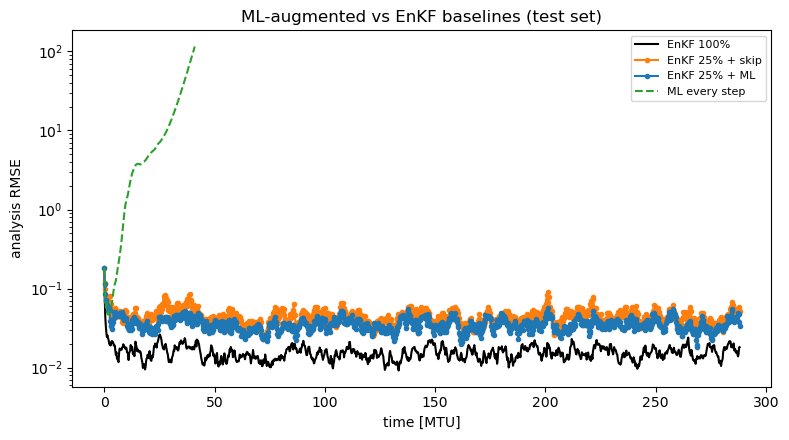

mean analysis RMSE (2nd half):
  EnKF 100%         : 0.0157
  EnKF 25% + skip   : 0.0437
  EnKF 25% + ML     : 0.0353
  ML every step     : nan


C:\Users\serg_\AppData\Local\Temp\ipykernel_22248\3412005444.py:11: RuntimeWarning: Mean of empty slice
  v=r["rmse_a"].values; print(f"  {label:18s}: {np.nanmean(v[len(v)//2:]):.4f}")


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
styles={"EnKF 100%":"k-","EnKF 25% + skip":"C1-o","EnKF 25% + ML":"C0-o","ML every step":"C2--"}
for label, r in results.items():
    ax.semilogy(r["time"], r["rmse_a"], styles.get(label,"-"), ms=3, label=label)
ax.set_xlabel("time [MTU]"); ax.set_ylabel("analysis RMSE")
ax.set_title("ML-augmented vs EnKF baselines (test set)"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("mean analysis RMSE (2nd half):")
for label, r in results.items():
    v=r["rmse_a"].values; print(f"  {label:18s}: {np.nanmean(v[len(v)//2:]):.4f}")

EnKF 100%
EnKF 25% + skip
EnKF 25% + ML


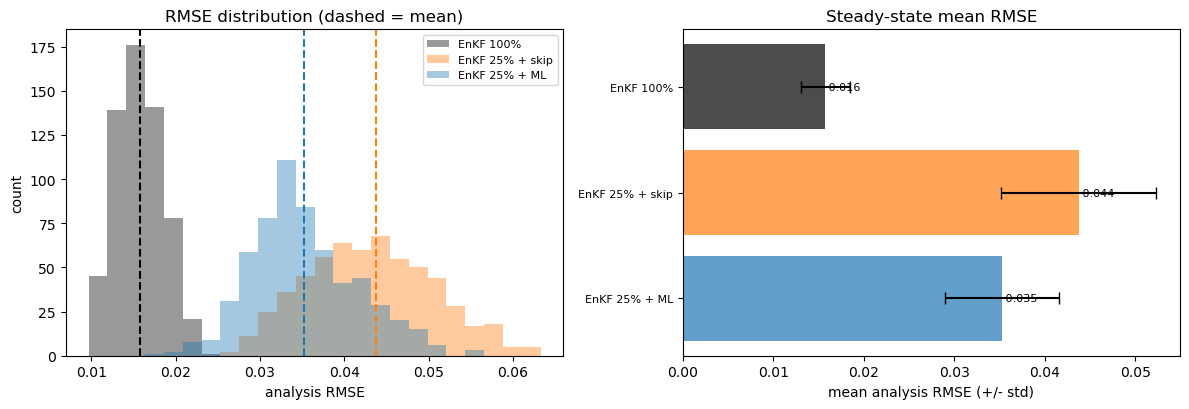

In [10]:
results_no_ml_only = {k:v for k,v in results.items() if k != "ML every step"}

# steady-state per-cycle RMSE (drop the filter spin-up: first half, and NaNs)
dists = {}
for label, r in results_no_ml_only.items():
    print(label)
    v = r["rmse_a"].values
    half = v[len(v) // 2:]
    half = half[np.isfinite(half)]
    if half.size:
        dists[label] = half

if not dists:
    print("no finite RMSE values to plot")
else:
    colors = {"EnKF 100%": "k", "EnKF 25% + skip": "C1",
              "EnKF 25% + ML": "C0", "ML every step": "C2"}
    lo = min(d.min() for d in dists.values())
    hi = max(np.percentile(d, 98) for d in dists.values())
    bins = np.linspace(lo, hi, 25) if hi > lo else 25

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

    # overlaid histograms with mean lines
    for label, d in dists.items():
        c = colors.get(label)
        ax[0].hist(d, bins=bins, alpha=0.4, color=c, label=label)
        ax[0].axvline(d.mean(), color=c, ls="--", lw=1.5)
    ax[0].set_xlabel("analysis RMSE"); ax[0].set_ylabel("count")
    ax[0].set_title("RMSE distribution (dashed = mean)"); ax[0].legend(fontsize=8)

    # mean +/- std summary
    labels = list(dists); means = [dists[l].mean() for l in labels]
    stds = [dists[l].std() for l in labels]
    y = np.arange(len(labels))
    ax[1].barh(y, means, xerr=stds, color=[colors.get(l) for l in labels], alpha=0.7, capsize=4)
    for yi, m in zip(y, means):
        ax[1].text(m, yi, f" {m:.3f}", va="center", fontsize=8)
    ax[1].set_yticks(y); ax[1].set_yticklabels(labels, fontsize=8); ax[1].invert_yaxis()
    ax[1].set_xlabel("mean analysis RMSE (+/- std)"); ax[1].set_title("Steady-state mean RMSE")
    fig.tight_layout(); plt.show()

## Notes

* The CNN was trained on the *dense-obs* EnKF analysis (notebook 04); here the ML
  step reads the dense test observations via `ml_obs`, matching its training.
* `schedule` supports arbitrary patterns — e.g. compare `["enkf","skip","skip"]`
  vs `["enkf","ml","skip"]` by changing that one list.